# Module 1 - Lesson 1 - Lab 2: Building and Visualizing Word Frequencies

**Objective:** In this lab, we will focus on the `build_freqs()` helper function and visualizing a dataset fed into it. In our goal of tweet sentiment analysis, this function will build a dictionary where we can lookup how many times a word appears in the lists of positive or negative tweets.

---

## Table of Contents

1. [Required Dependencies](#dependencies)
2. [Import Libraries](#imports)
3. [Understanding the build_freqs() Function](#theory)
4. [Loading the Dataset](#data)
5. [Implementing build_freqs()](#implementation)
6. [Visualizing Word Frequencies](#visualization)
7. [Practice Exercises](#exercises)

---

## 1. Required Dependencies <a name="dependencies"></a>

**Install karne ke liye required packages:**

```bash
pip install nltk numpy pandas matplotlib seaborn
```

**Agar course-specific dataset chahiye toh:**

```bash
pip install utils   # Course helper functions ke liye
```

**Note:** Is notebook mein hum sample data create karenge taake aap bina external files ke bhi run kar saken.

## 2. Import Libraries <a name="imports"></a>

In [16]:
# Basic libraries
import numpy as np
import pandas as pd
from collections import defaultdict

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
import string
import re

# Download required NLTK data
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to C:\Users\Mubashir
[nltk_data]     Ijaz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 3. Understanding the build_freqs() Function <a name="theory"></a>

### Kya kaam karta hai?

`build_freqs()` function ek dictionary banata hai jisme:
- **Key:** (word, label) tuple
  - `word` = individual word from tweet
  - `label` = 1 (positive) ya 0 (negative)
- **Value:** Frequency count (kitni baar word aaya)

### Example:
```python
freqs = {
    ('happy', 1): 15,      # 'happy' 15 times in positive tweets
    ('happy', 0): 2,       # 'happy' 2 times in negative tweets
    ('sad', 1): 1,         # 'sad' 1 time in positive tweets
    ('sad', 0): 20,        # 'sad' 20 times in negative tweets
}
```

### Why is this useful?
- Feature extraction ke time hum easily dekh sakte hain ki ek word positive tweets mein zyada aata hai ya negative mein
- Sentiment analysis model training ke liye important features provide karta hai

## 4. Loading the Dataset <a name="data"></a>

**Note:** Aapke course mein usually `positive_tweets.json` aur `negative_tweets.json` files hoti hain. Yahan hum sample data create karenge for demonstration.

In [17]:
# Sample tweets for demonstration
# In actual course, load from: nltk.corpus.twitter_samples

positive_tweets = [
    "Happy to announce that I got the job! #blessed #happy",
    "What a beautiful day! Feeling great :)",
    "Love this new restaurant! Amazing food and service",
    "So grateful for my friends and family",
    "Just finished a great workout! Feeling strong",
    "Beautiful sunset today! Nature is amazing",
    "Happy birthday to my best friend! Love you",
    "Excited for the weekend! Going to the beach",
    "This movie was absolutely fantastic! Loved it",
    "So happy with my progress! Keep pushing forward",
    "Great team meeting today! Productive discussions",
    "Love my new puppy! He is so cute and playful",
    "Amazing concert last night! Best performance ever",
    "Feeling blessed and grateful today",
    "Wonderful news! Got accepted to my dream school",
    "Happy to help others! Volunteering today",
    "Beautiful wedding! So happy for the couple",
    "Love this song! Makes me so happy",
    "Great workout this morning! Feeling energized",
    "So proud of my team! We did it!"
]

negative_tweets = [
    "So sad today. Everything is going wrong",
    "Hate this weather! So gloomy and depressing",
    "Terrible service at this restaurant. Never coming back",
    "Feeling down and frustrated with work",
    "Bad news today. Really upset about it",
    "This movie was horrible. Waste of time",
    "So angry right now! Can't believe this happened",
    "Hate waiting in long lines! So frustrating",
    "Terrible day at work. Everything went wrong",
    "Sad to hear about the accident. Praying for everyone",
    "This food is disgusting. Can't eat this",
    "Feeling lonely and depressed today",
    "Hate traffic! Stuck here for hours",
    "Bad experience with customer service. Very disappointed",
    "So tired of all the negativity around me",
    "Angry about the delay! No explanation given",
    "Hate when people are rude for no reason",
    "Terrible headache today. Feeling awful",
    "So sad to see friends leaving. Will miss them",
    "Bad quality product. Complete waste of money"
]

print(f"Total positive tweets: {len(positive_tweets)}")
print(f"Total negative tweets: {len(negative_tweets)}")

Total positive tweets: 20
Total negative tweets: 20


### Data Preprocessing Functions

In [18]:
def process_tweet(tweet):
    """
    Tweet ko clean aur tokenize karta hai.
    
    Steps:
    1. Remove stock market tickers like $GE
    2. Remove old style retweet text "RT"
    3. Remove hyperlinks
    4. Remove hashtags (only the # sign)
    5. Tokenize
    6. Remove stopwords and punctuation
    
    Args:
        tweet: String containing the tweet
    
    Returns:
        List of cleaned word tokens
    """
    # Convert to lowercase
    tweet = tweet.lower()
    
    # Remove stock market tickers like $GE
    tweet = re.sub(r'\$\w*', '', tweet)
    
    # Remove old style retweet text "RT"
    tweet = re.sub(r'^rt[\s]+', '', tweet)
    
    # Remove hyperlinks
    tweet = re.sub(r'https?:\//.*[\r\n]*', '', tweet)
    
    # Remove hashtags (only the # sign)
    tweet = re.sub(r'#', '', tweet)
    
    # Tokenize using TweetTokenizer
    tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=True)
    tweet_tokens = tokenizer.tokenize(tweet)
    
    # Remove stopwords and punctuation
    stopwords_english = stopwords.words('english')
    tweets_clean = []
    
    for word in tweet_tokens:
        if word not in stopwords_english and word not in string.punctuation:
            tweets_clean.append(word)
    
    return tweets_clean

# Test the function
sample_tweet = "Happy to announce that I got the job! #blessed #happy :)"
print(f"Original: {sample_tweet}")
print(f"Processed: {process_tweet(sample_tweet)}")

Original: Happy to announce that I got the job! #blessed #happy :)
Processed: ['happy', 'announce', 'got', 'job', 'blessed', 'happy', ':)']


## 5. Implementing build_freqs() <a name="implementation"></a>

### Function Signature:
```python
def build_freqs(tweets, ys):
    """
    Args:
        tweets: List of tweets
        ys: Labels (0 or 1) corresponding to each tweet
    
    Returns:
        freqs: Dictionary with (word, label) as key and frequency as value
    """
```

In [19]:
def build_freqs(tweets, ys):
    """
    Build frequencies dictionary.
    
    Args:
        tweets: List of tweets (strings)
        ys: m x 1 array with sentiment label (0 or 1) for each tweet
    
    Returns:
        freqs: Dictionary mapping (word, label) to frequency count
               Example: {('happy', 1): 10, ('happy', 0): 2, ...}
    """
    # Convert ys to list (in case it's numpy array)
    yslist = np.squeeze(ys).tolist()
    
    # Start with empty dictionary
    freqs = {}
    
    # Loop through each tweet and its label
    for y, tweet in zip(yslist, tweets):
        # Process the tweet to get cleaned word tokens
        for word in process_tweet(tweet):
            # Create pair (word, label)
            pair = (word, y)
            
            # Update frequency count
            if pair in freqs:
                freqs[pair] += 1
            else:
                freqs[pair] = 1
    
    return freqs

print("✓ build_freqs() function defined successfully!")

✓ build_freqs() function defined successfully!


### Creating Training Data

In [20]:
# Combine all tweets
all_tweets = positive_tweets + negative_tweets

# Create labels: 1 for positive, 0 for negative
labels = np.append(
    np.ones((len(positive_tweets), 1)),    # Positive = 1
    np.zeros((len(negative_tweets), 1)),   # Negative = 0
    axis=0
)

print(f"Total tweets: {len(all_tweets)}")
print(f"Labels shape: {labels.shape}")
print(f"\nFirst 5 labels:\n{labels[:5]}")
print(f"\nLast 5 labels:\n{labels[-5:]}")

Total tweets: 40
Labels shape: (40, 1)

First 5 labels:
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]]

Last 5 labels:
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


### Building the Frequencies Dictionary

In [21]:
# Build frequencies
freqs = build_freqs(all_tweets, labels)

print(f"Total unique (word, label) pairs: {len(freqs)}")
print("\n" + "="*50)
print("Sample frequencies:")
print("="*50)

# Show some examples
sample_words = ['happy', 'sad', 'love', 'hate', 'great', 'terrible', 'good', 'bad']
for word in sample_words:
    pos_count = freqs.get((word, 1.0), 0)  # Positive count
    neg_count = freqs.get((word, 0.0), 0)  # Negative count
    print(f"'{word}' -> Positive: {pos_count}, Negative: {neg_count}")

Total unique (word, label) pairs: 138

Sample frequencies:
'happy' -> Positive: 7, Negative: 0
'sad' -> Positive: 0, Negative: 3
'love' -> Positive: 4, Negative: 0
'hate' -> Positive: 0, Negative: 4
'great' -> Positive: 4, Negative: 0
'terrible' -> Positive: 0, Negative: 3
'good' -> Positive: 0, Negative: 0
'bad' -> Positive: 0, Negative: 3


### Understanding the Output Format

In [22]:
# Let's see the actual dictionary structure
print("Dictionary keys are (word, label) tuples:\n")

# Show first 10 entries
for i, (key, value) in enumerate(freqs.items()):
    print(f"Key: {key}, Value: {value}")
    if i >= 9:
        break

print("\n" + "="*50)
print("How to lookup:")
print("="*50)
print("freqs.get(('happy', 1.0)) =", freqs.get(('happy', 1.0), 0))
print("freqs.get(('happy', 0.0)) =", freqs.get(('happy', 0.0), 0))

Dictionary keys are (word, label) tuples:

Key: ('happy', 1.0), Value: 7
Key: ('announce', 1.0), Value: 1
Key: ('got', 1.0), Value: 2
Key: ('job', 1.0), Value: 1
Key: ('blessed', 1.0), Value: 2
Key: ('beautiful', 1.0), Value: 3
Key: ('day', 1.0), Value: 1
Key: ('feeling', 1.0), Value: 4
Key: ('great', 1.0), Value: 4
Key: (':)', 1.0), Value: 1

How to lookup:
freqs.get(('happy', 1.0)) = 7
freqs.get(('happy', 0.0)) = 0


## 6. Visualizing Word Frequencies <a name="visualization"></a>

### 6.1 Top Words in Positive Tweets

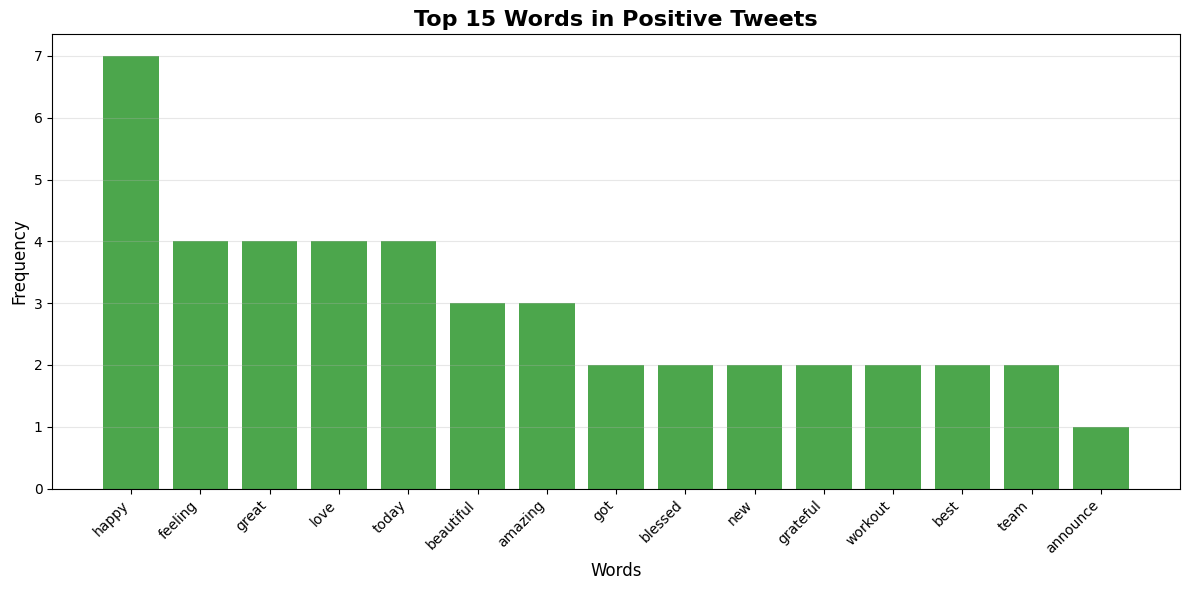

In [23]:
# Extract positive frequencies
pos_freqs = {k[0]: v for k, v in freqs.items() if k[1] == 1.0}

# Sort by frequency
pos_sorted = sorted(pos_freqs.items(), key=lambda x: x[1], reverse=True)

# Top 15 positive words
top_pos = pos_sorted[:15]
words = [w[0] for w in top_pos]
counts = [w[1] for w in top_pos]

# Plot
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='green', alpha=0.7)
plt.title('Top 15 Words in Positive Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

### 6.2 Top Words in Negative Tweets

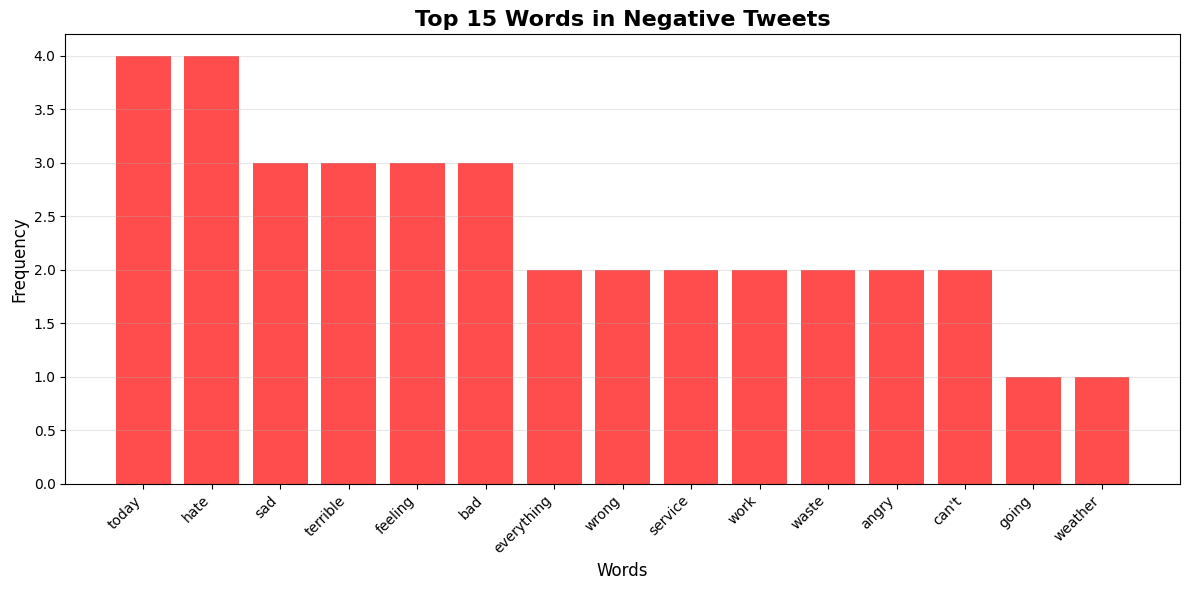

In [24]:
# Extract negative frequencies
neg_freqs = {k[0]: v for k, v in freqs.items() if k[1] == 0.0}

# Sort by frequency
neg_sorted = sorted(neg_freqs.items(), key=lambda x: x[1], reverse=True)

# Top 15 negative words
top_neg = neg_sorted[:15]
words = [w[0] for w in top_neg]
counts = [w[1] for w in top_neg]

# Plot
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='red', alpha=0.7)
plt.title('Top 15 Words in Negative Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

### 6.3 Comparative Visualization: Positive vs Negative

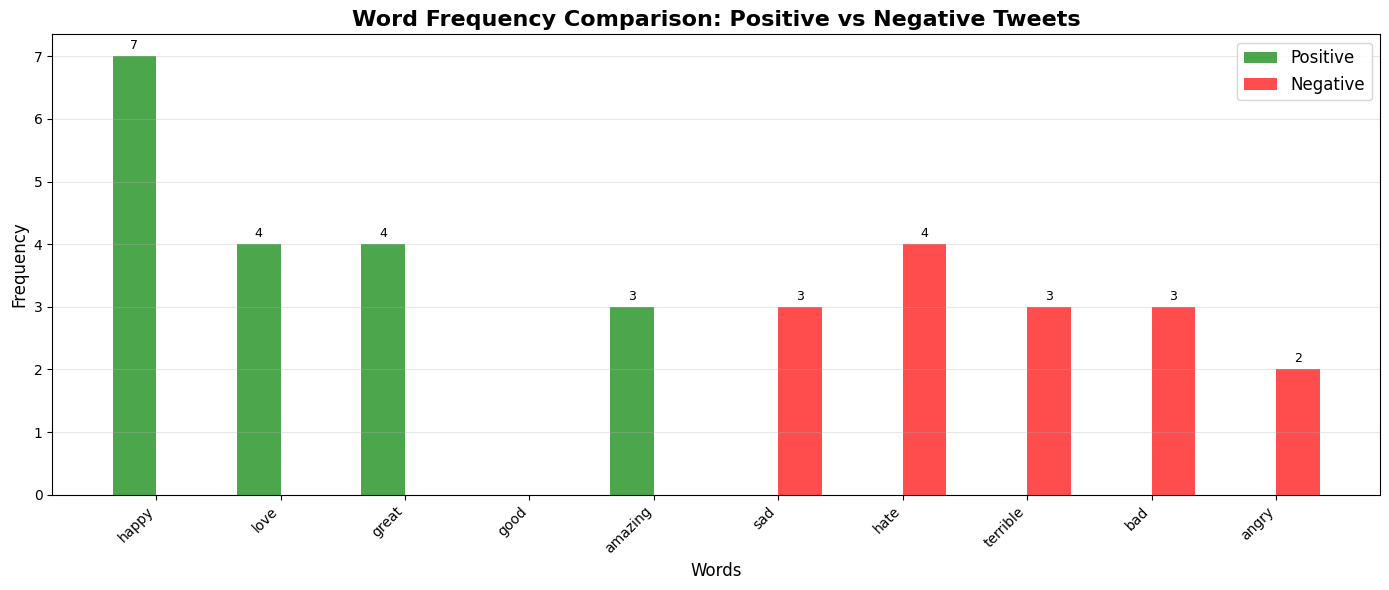

In [25]:
# Select common words to compare
common_words = ['happy', 'love', 'great', 'good', 'amazing', 'sad', 'hate', 'terrible', 'bad', 'angry']

pos_counts = [freqs.get((w, 1.0), 0) for w in common_words]
neg_counts = [freqs.get((w, 0.0), 0) for w in common_words]

x = np.arange(len(common_words))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, pos_counts, width, label='Positive', color='green', alpha=0.7)
bars2 = ax.bar(x + width/2, neg_counts, width, label='Negative', color='red', alpha=0.7)

ax.set_xlabel('Words', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Word Frequency Comparison: Positive vs Negative Tweets', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(common_words, rotation=45, ha='right')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.show()

### 6.4 Scatter Plot: Word Sentiment Analysis

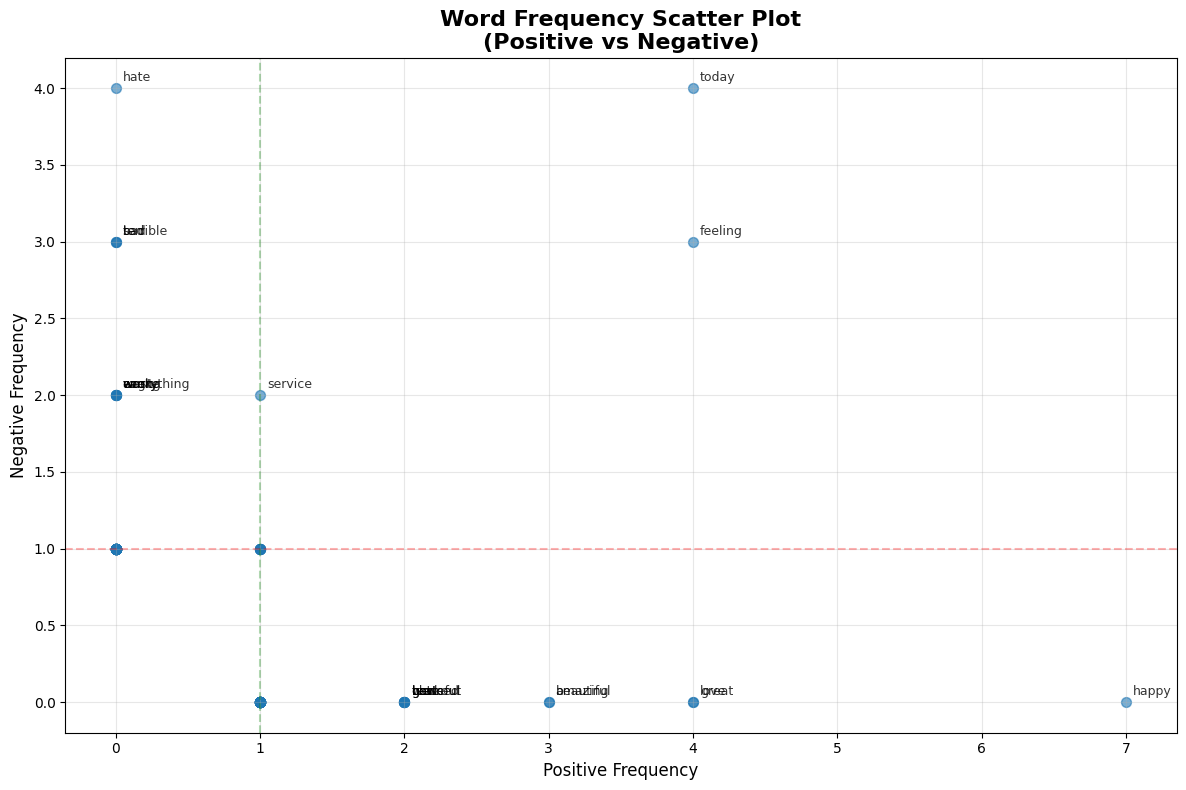

In [26]:
# Get all unique words
all_words = list(set([k[0] for k in freqs.keys()]))

# Create data for scatter plot
pos_counts = []
neg_counts = []
word_labels = []

for word in all_words:
    pos = freqs.get((word, 1.0), 0)
    neg = freqs.get((word, 0.0), 0)
    # Only include words that appear at least once
    if pos > 0 or neg > 0:
        pos_counts.append(pos)
        neg_counts.append(neg)
        word_labels.append(word)

# Create scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(pos_counts, neg_counts, alpha=0.6, s=50)

# Add word labels for interesting points
for i, word in enumerate(word_labels):
    # Label words that appear frequently in one class but not the other
    if pos_counts[i] > 1 or neg_counts[i] > 1:
        plt.annotate(word, (pos_counts[i], neg_counts[i]), 
                    xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, alpha=0.8)

plt.xlabel('Positive Frequency', fontsize=12)
plt.ylabel('Negative Frequency', fontsize=12)
plt.title('Word Frequency Scatter Plot\n(Positive vs Negative)', fontsize=16, fontweight='bold')
plt.axhline(y=1, color='r', linestyle='--', alpha=0.3)
plt.axvline(x=1, color='g', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.5 Word Cloud Style Visualization (Top 20 Words)

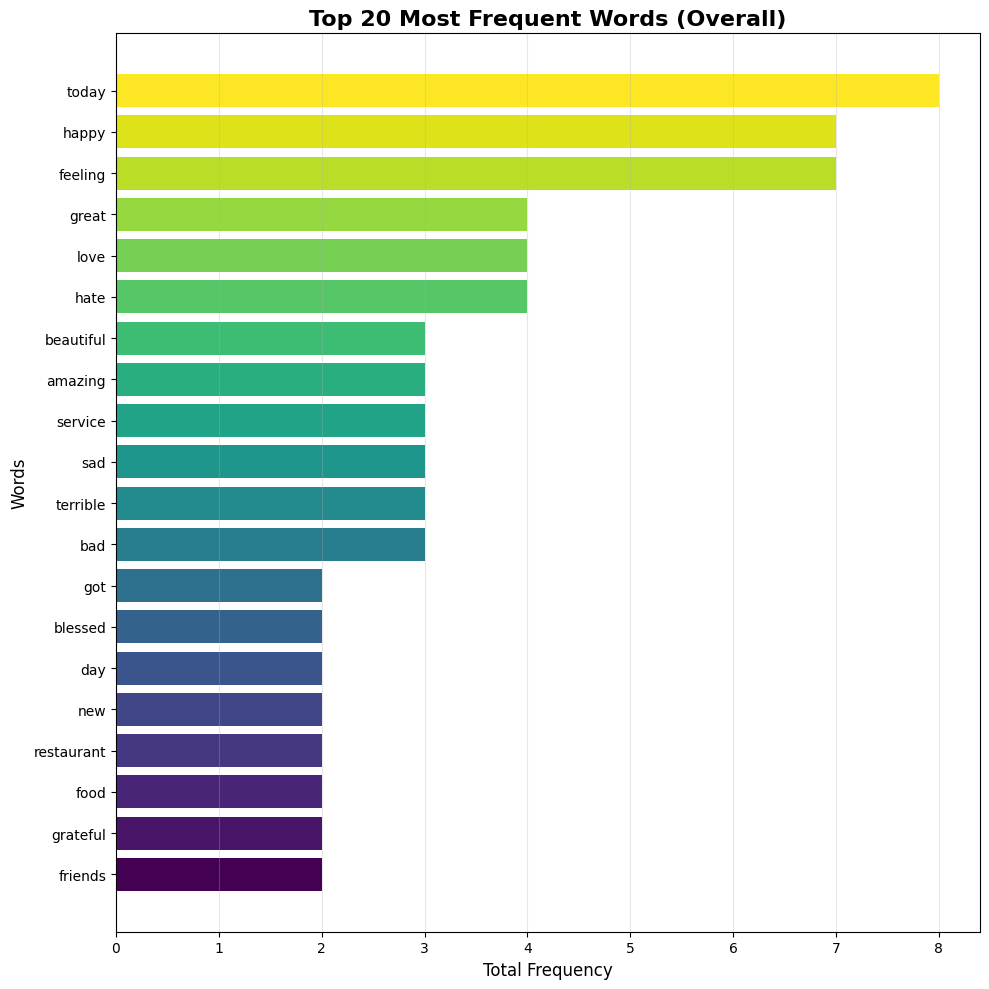

In [27]:
# Get top 20 words overall
all_freqs = {}
for (word, label), count in freqs.items():
    if word not in all_freqs:
        all_freqs[word] = 0
    all_freqs[word] += count

top_20 = sorted(all_freqs.items(), key=lambda x: x[1], reverse=True)[:20]

# Create horizontal bar chart
words = [w[0] for w in top_20]
counts = [w[1] for w in top_20]

plt.figure(figsize=(10, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(words)))
plt.barh(words[::-1], counts[::-1], color=colors)
plt.xlabel('Total Frequency', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.title('Top 20 Most Frequent Words (Overall)', fontsize=16, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Practice Exercises <a name="exercises"></a>

### Exercise 1: Find Most Positive Words
Un words ko identify karo jo sirf positive tweets mein aate hain (negative mein nahi).

In [28]:
# Exercise 1 Solution
only_positive = []

for word in all_words:
    pos = freqs.get((word, 1.0), 0)
    neg = freqs.get((word, 0.0), 0)
    if pos > 0 and neg == 0:
        only_positive.append((word, pos))

# Sort by frequency
only_positive.sort(key=lambda x: x[1], reverse=True)

print("Words appearing ONLY in positive tweets:\n")
for word, count in only_positive[:10]:
    print(f"  {word}: {count} times")

Words appearing ONLY in positive tweets:

  happy: 7 times
  love: 4 times
  great: 4 times
  amazing: 3 times
  beautiful: 3 times
  workout: 2 times
  got: 2 times
  new: 2 times
  blessed: 2 times
  best: 2 times


### Exercise 2: Find Most Negative Words
Un words ko identify karo jo sirf negative tweets mein aate hain.

In [29]:
# Exercise 2 Solution
only_negative = []

for word in all_words:
    pos = freqs.get((word, 1.0), 0)
    neg = freqs.get((word, 0.0), 0)
    if neg > 0 and pos == 0:
        only_negative.append((word, neg))

# Sort by frequency
only_negative.sort(key=lambda x: x[1], reverse=True)

print("Words appearing ONLY in negative tweets:\n")
for word, count in only_negative[:10]:
    print(f"  {word}: {count} times")

Words appearing ONLY in negative tweets:

  hate: 4 times
  terrible: 3 times
  bad: 3 times
  sad: 3 times
  everything: 2 times
  can't: 2 times
  wrong: 2 times
  work: 2 times
  angry: 2 times
  waste: 2 times


### Exercise 3: Sentiment Ratio Analysis
Un words ko find karo jinka positive-to-negative ratio sabse zyada hai.

In [30]:
# Exercise 3 Solution
sentiment_ratios = []

for word in all_words:
    pos = freqs.get((word, 1.0), 0)
    neg = freqs.get((word, 0.0), 0)
    
    # Only consider words that appear at least twice overall
    if pos + neg >= 2:
        # Calculate ratio (add 1 to avoid division by zero)
        ratio = (pos + 1) / (neg + 1)
        sentiment_ratios.append((word, ratio, pos, neg))

# Sort by ratio (descending)
sentiment_ratios.sort(key=lambda x: x[1], reverse=True)

print("Words with HIGHEST positive sentiment ratio:\n")
for word, ratio, pos, neg in sentiment_ratios[:10]:
    print(f"  {word}: ratio={ratio:.2f} (pos={pos}, neg={neg})")

print("\n" + "="*50)
print("Words with LOWEST sentiment ratio (most negative):\n")
for word, ratio, pos, neg in sentiment_ratios[-10:]:
    print(f"  {word}: ratio={ratio:.2f} (pos={pos}, neg={neg})")

Words with HIGHEST positive sentiment ratio:

  happy: ratio=8.00 (pos=7, neg=0)
  love: ratio=5.00 (pos=4, neg=0)
  great: ratio=5.00 (pos=4, neg=0)
  amazing: ratio=4.00 (pos=3, neg=0)
  beautiful: ratio=4.00 (pos=3, neg=0)
  workout: ratio=3.00 (pos=2, neg=0)
  got: ratio=3.00 (pos=2, neg=0)
  new: ratio=3.00 (pos=2, neg=0)
  blessed: ratio=3.00 (pos=2, neg=0)
  best: ratio=3.00 (pos=2, neg=0)

Words with LOWEST sentiment ratio (most negative):

  everything: ratio=0.33 (pos=0, neg=2)
  can't: ratio=0.33 (pos=0, neg=2)
  wrong: ratio=0.33 (pos=0, neg=2)
  work: ratio=0.33 (pos=0, neg=2)
  angry: ratio=0.33 (pos=0, neg=2)
  waste: ratio=0.33 (pos=0, neg=2)
  terrible: ratio=0.25 (pos=0, neg=3)
  bad: ratio=0.25 (pos=0, neg=3)
  sad: ratio=0.25 (pos=0, neg=3)
  hate: ratio=0.20 (pos=0, neg=4)


---

## Summary

Is lab mein humne seekha:

1. **`build_freqs()` function**: Ek dictionary banata hai jisme `(word, label)` pairs ki frequency store hoti hai
2. **Data preprocessing**: Tweets ko clean karna (lowercase, remove URLs, hashtags, stopwords, etc.)
3. **Visualization techniques**:
   - Bar charts for top words
   - Comparative positive vs negative
   - Scatter plots for sentiment analysis
   - Horizontal bar charts

### Key Takeaways:
- `build_freqs()` feature extraction ke liye important hai
- Word frequencies se hum samajh sakte hain ki kaunse words positive/negative sentiment indicate karte hain
- Visualization se patterns easily identify ho sakte hain

---

## Next Steps

Programming assignment mein aap:
- `build_freqs()` use karke features extract karoge
- Logistic regression model train karoge
- Tweet sentiment predict karoge